In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

In [15]:
# Constants
hbar = 1.0  # Planck's constant (reduced)
m = 1.0     # Particle mass
G = 1.0     # Gravitational constant
a = 1.0     # Initial separation
dt = 0.01   # Time step
t_max = 1000  # Total simulation time
N = 1000    # Number of spatial points
L = 100.0    # Length of the spatial domain

In [16]:
# Spatial grid
x = np.linspace(-L/2, L/2, N)
dx = x[1] - x[0]

# Initialize wave functions (Gaussian form)
sigma = 0.5  # Width of the Gaussian
X1_0 = -a / 2  # Initial position of particle 1
X2_0 = a / 2   # Initial position of particle 2

psi1 = np.exp(-((x - X1_0)**2) / (2 * sigma**2)) * np.exp(1j * 0.0)  # Centered at X1_0
psi2 = np.exp(-((x - X2_0)**2) / (2 * sigma**2)) * np.exp(1j * 0.1)  # Centered at X2_0

In [17]:
# Normalize wave functions
psi1 /= np.sqrt(np.sum(np.abs(psi1)**2) * dx)
psi2 /= np.sqrt(np.sum(np.abs(psi2)**2) * dx)

# Initial positions
X1 = X1_0
X2 = X2_0

# Time evolution setup
k = fftfreq(N, d=dx) * 2 * np.pi
k2 = k**2

# Storage for trajectories
trajectory1 = [X1]
trajectory2 = [X2]

In [18]:
# Time evolution loop
for t in np.arange(0, t_max, dt):
    # Compute feedback terms
    F1_1 = G * m * m * (x - X2) / np.abs(x - X2)**3 - (X1 - X2) / np.abs(X1 - X2)**3
    F2_1 = G * m * m * (x - X1) / np.abs(x - X1)**3 - (X1 - X2) / np.abs(X1 - X2)**3

    F1_2 = G * m * m * (3 * (x - X2)**3 - np.abs(x - X2))/ np.abs(x - X2)**6 - (3 * (X1 - X2)**3 - np.abs(X1 - X2))/ np.abs(X1 - X2)**6
    F2_2 = G * m * m * (3 * (x - X1)**3 - np.abs(x - X1))/ np.abs(x - X1)**6 - (3 * (X1 - X2)**3 - np.abs(X1 - X2))/ np.abs(X1 - X2)**6
    
    # Update wave functions using the Schrödinger equation (Fourier space)
    psi1_k = fft(psi1)
    psi2_k = fft(psi2)
    
    psi1_k = psi1_k * np.exp(-1j * (hbar * k2 / (2 * m) + F1_1 + F1_2) * dt)
    psi2_k = psi2_k * np.exp(-1j * (hbar * k2 / (2 * m) + F2_1 + F2_2) * dt)
    
    psi1 = ifft(psi1_k)
    psi2 = ifft(psi2_k)
    
    # Normalize wave functions
    psi1 /= np.sqrt(np.sum(np.abs(psi1)**2) * dx)
    psi2 /= np.sqrt(np.sum(np.abs(psi2)**2) * dx)
    
    # Update particle positions (guidance equation)
    velocity1 = (hbar / m) * np.imag(np.gradient(np.log(psi1)))[np.abs(x - X1).argmin()]
    velocity2 = (hbar / m) * np.imag(np.gradient(np.log(psi2)))[np.abs(x - X2).argmin()]
    
    X1 += velocity1 * dt
    X2 += velocity2 * dt
    
    # Store trajectories
    trajectory1.append(X1)
    trajectory2.append(X2)

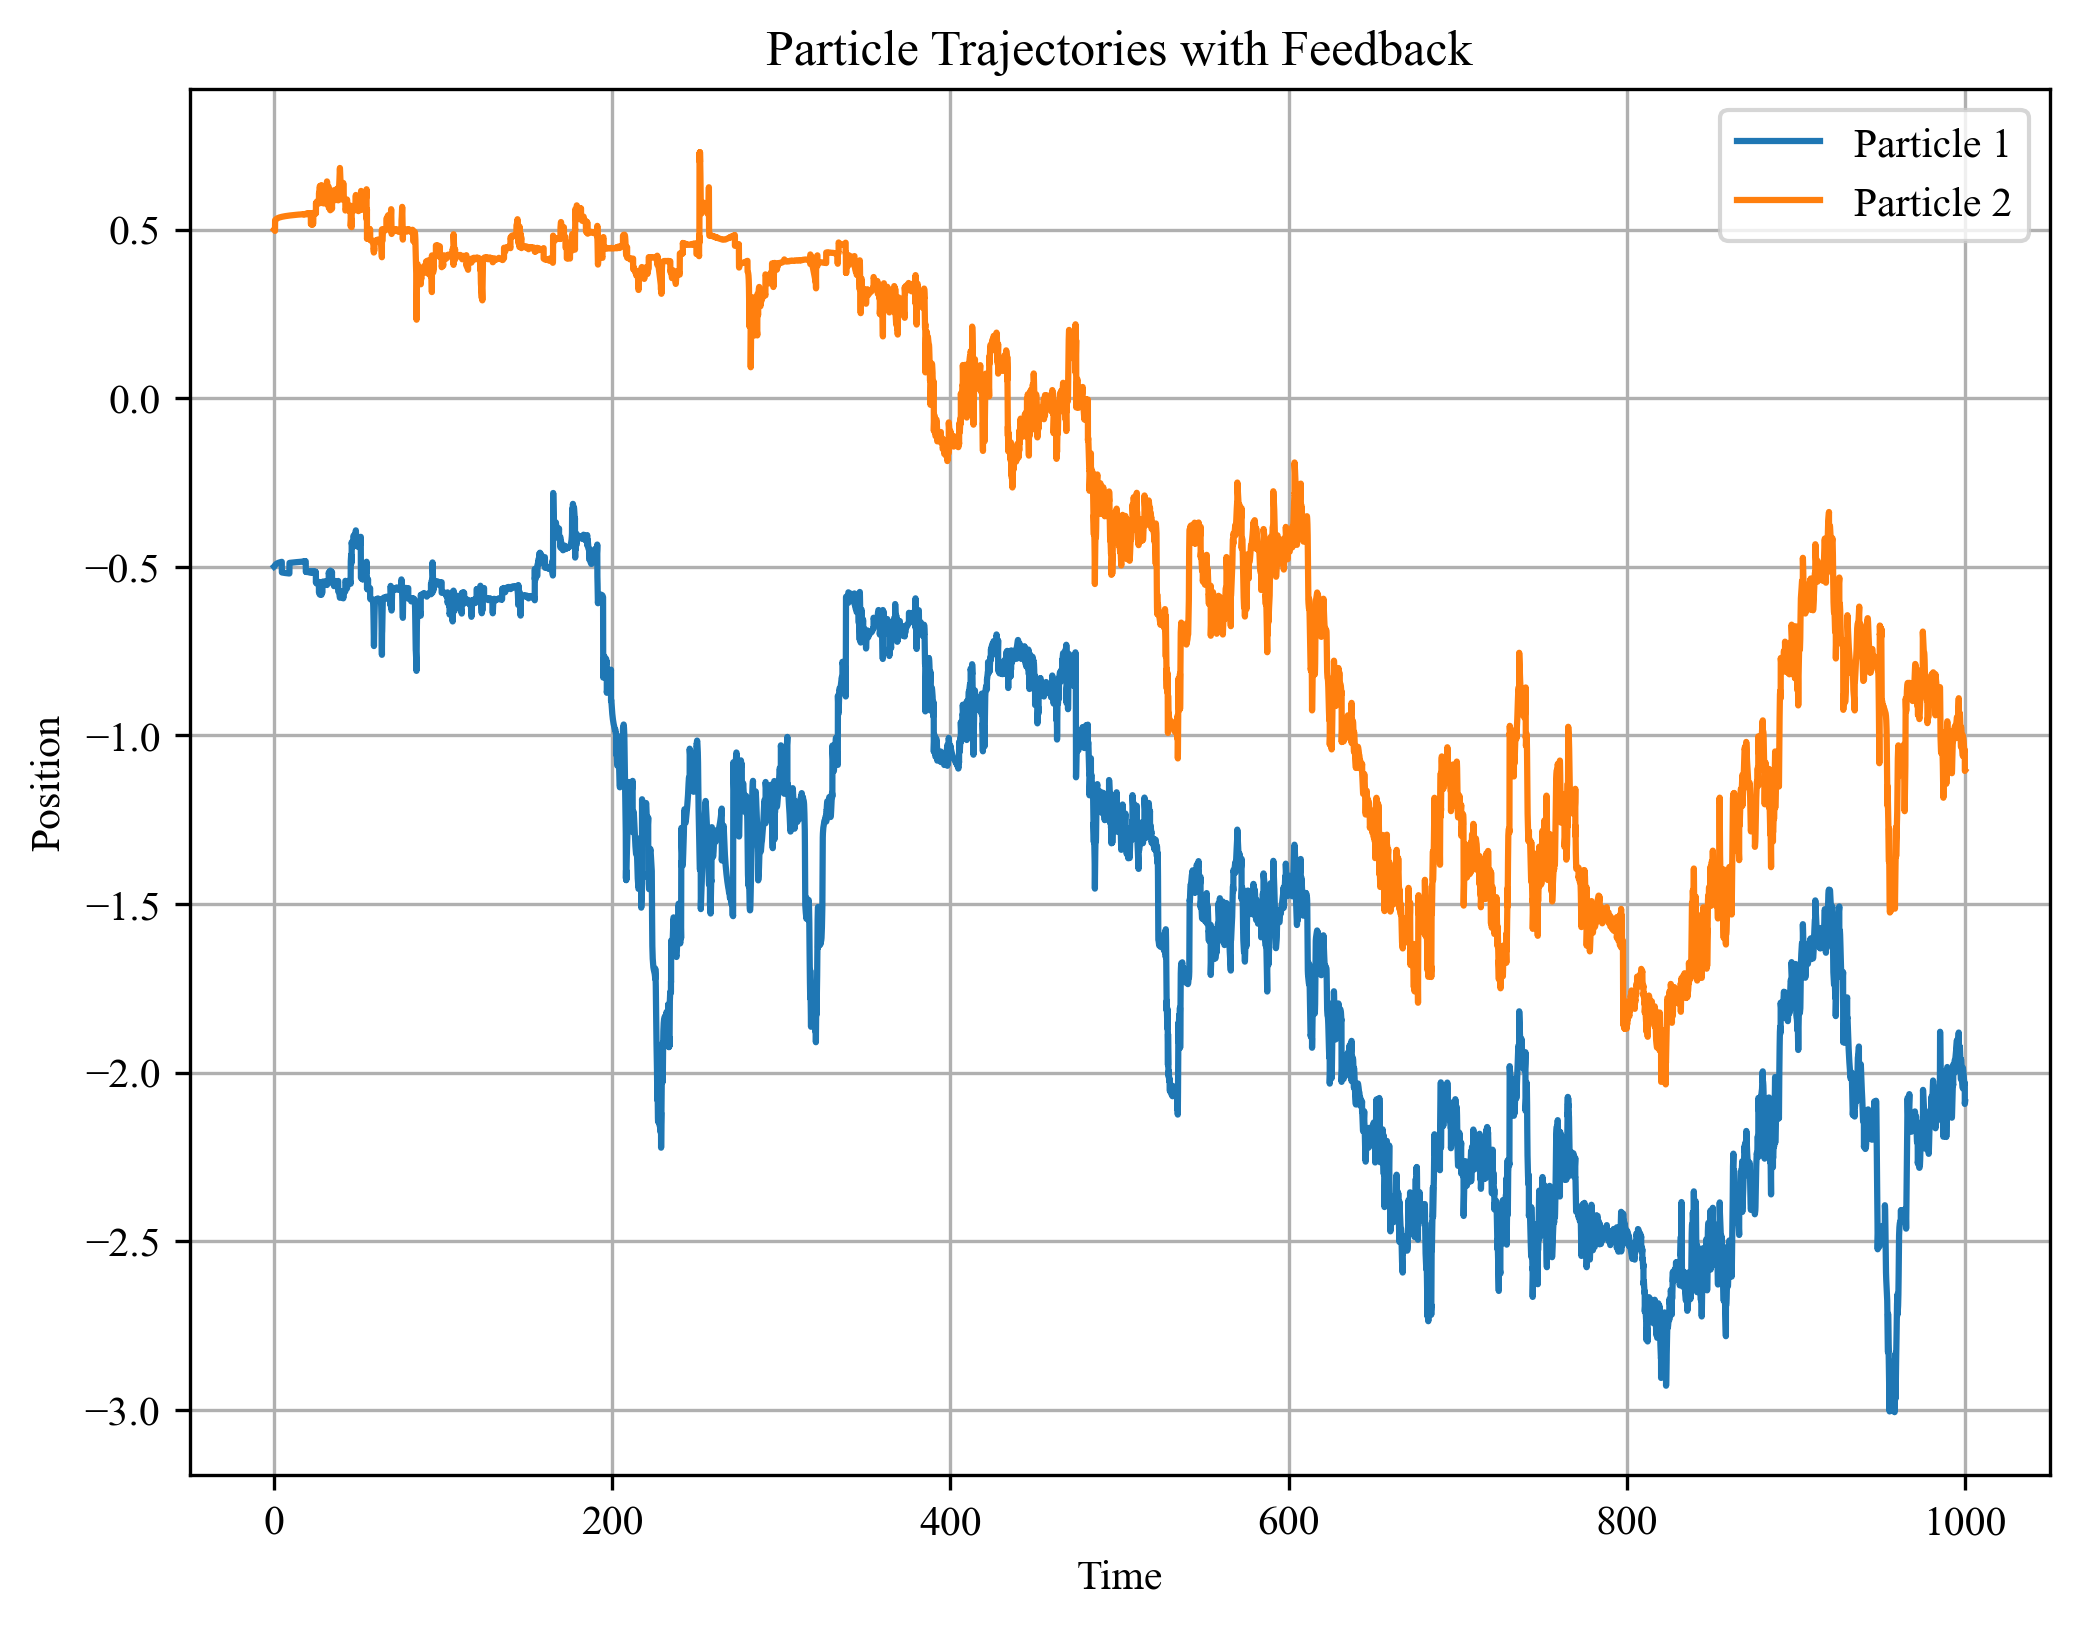

In [19]:
# Plot trajectories
plt.rcParams["font.family"] = "Times New Roman"
plt.figure(figsize=(8, 6), dpi=300) # Increased DPI to 300 for higher resolution
plt.plot(np.arange(0, t_max + dt, dt), trajectory1, label="Particle 1")
plt.plot(np.arange(0, t_max + dt, dt), trajectory2, label="Particle 2")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Particle Trajectories with Feedback")
plt.legend()
plt.grid()
plt.show()